# Notebook 5: Parameter Tuning & Sanity Checks
The Goal: Stop building "blind." This notebook visualizes the raw distributions of our math so we can logically select our thresholds (CV for Censoring, K for Clustering, Alpha for LightGBM) *before* we commit them to the main pipeline.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
abt = pd.read_parquet('../data/gold/model_input.parquet')


### 1. Visualizing the Censoring Threshold (Volume CV)
Currently, our pipeline uses `CV < 0.15` and flagged only 33 rows. Let's look at the actual distribution of CV across the network to pick a realistic threshold.


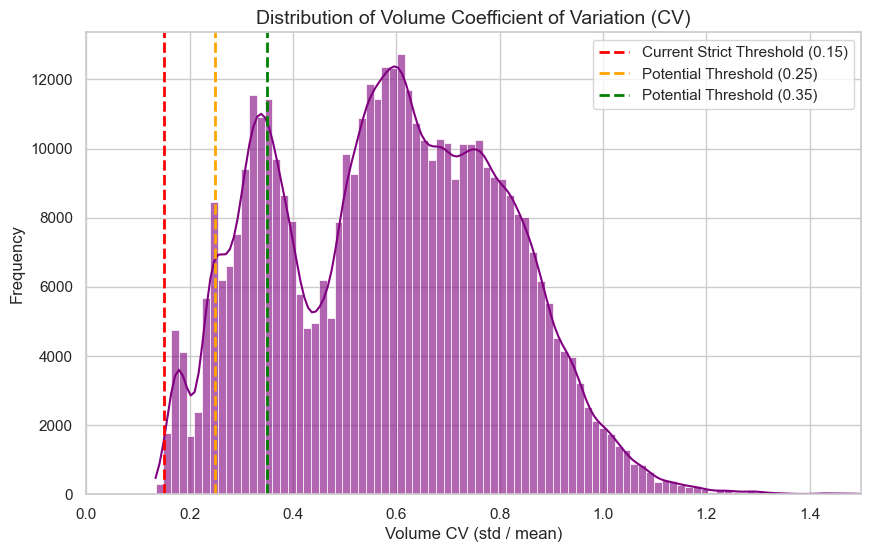

Rows caught at CV < 0.15: 341
Rows caught at CV < 0.25: 26875
Rows caught at CV < 0.35: 85474


In [2]:
# Calculate CV for all non-zero volume rows
cv_dist = abt[abt['Total_Volume'] > 0]['Volume_CV']

plt.figure(figsize=(10, 6))
sns.histplot(cv_dist, bins=100, kde=True, color='purple', alpha=0.6)

# Draw potential thresholds
plt.axvline(0.15, color='red', linestyle='--', linewidth=2, label='Current Strict Threshold (0.15)')
plt.axvline(0.25, color='orange', linestyle='--', linewidth=2, label='Potential Threshold (0.25)')
plt.axvline(0.35, color='green', linestyle='--', linewidth=2, label='Potential Threshold (0.35)')

plt.title("Distribution of Volume Coefficient of Variation (CV)", fontsize=14)
plt.xlabel("Volume CV (std / mean)")
plt.ylabel("Frequency")
plt.xlim(0, 1.5)
plt.legend()
plt.show()

print(f"Rows caught at CV < 0.15: {len(abt[(abt['Volume_CV'] < 0.15) & (abt['Total_Volume'] > 0)])}")
print(f"Rows caught at CV < 0.25: {len(abt[(abt['Volume_CV'] < 0.25) & (abt['Total_Volume'] > 0)])}")
print(f"Rows caught at CV < 0.35: {len(abt[(abt['Volume_CV'] < 0.35) & (abt['Total_Volume'] > 0)])}")


### 2. Validating the K-Means Elbow
We forced K=50 earlier. Let's see the actual Elbow curve.


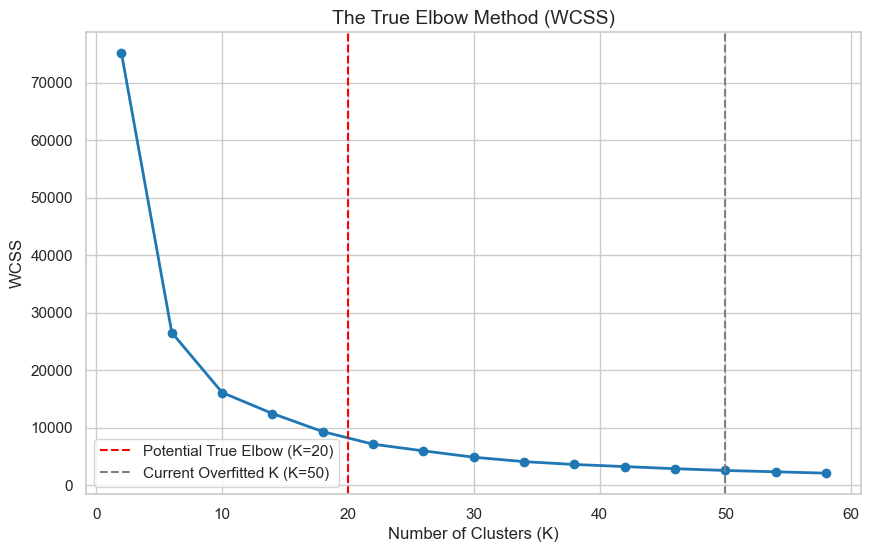

In [3]:
feature_cols = [
    "poi_total_catchment", "Tuition_Weekend_Surge", "Tourist_Peak_Multiplier", 
    "Sports_Big_Match_Spike", "Park_Poya_Outing", "Number_of_Weekends", "Holiday_Count"
]
X = abt[feature_cols].fillna(0).sample(min(15000, len(abt)), random_state=42)
X_scaled = StandardScaler().fit_transform(X)

wcss = []
K_range = range(2, 60, 4)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=1)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, 'bo-', color='#1f77b4', linewidth=2)
plt.axvline(20, color='red', linestyle='--', label='Potential True Elbow (K=20)')
plt.axvline(50, color='gray', linestyle='--', label='Current Overfitted K (K=50)')
plt.title('The True Elbow Method (WCSS)', fontsize=14)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.legend()
plt.show()


### 3. Tuning the LightGBM Quantile (Alpha)
An alpha of `0.90` (90th percentile) predicted a 102% network growth. Let's train models at alpha=0.75, 0.85, and 0.90 to see the total predicted volume.


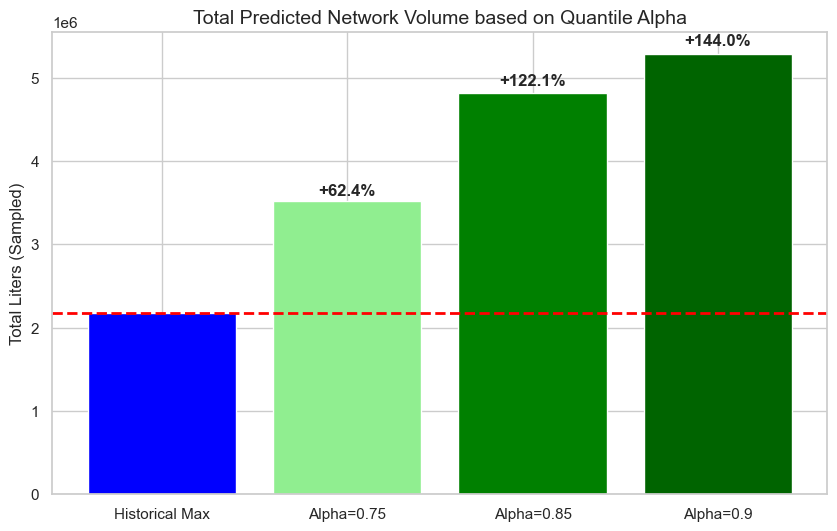

In [4]:
features = feature_cols + ["poi_count_school", "Has_Youth_Catchment", "Has_Leisure_Catchment", "Outlet_Type", "Dynamic_Tier"]
# We will use a fast 5000 sample for sandbox tuning
train_df = abt.sample(10000, random_state=42).copy()
for c in ["Outlet_Type", "Dynamic_Tier"]:
    train_df[c] = train_df[c].astype('category')

X_train = train_df[features]
y_train = train_df['Total_Volume']

alphas = [0.75, 0.85, 0.90]
results = {}

for alpha in alphas:
    model = lgb.LGBMRegressor(objective='quantile', alpha=alpha, n_estimators=50, random_state=42, verbose=-1)
    model.fit(X_train, y_train)
    # Predict back on the sample
    preds = model.predict(X_train)
    results[f'Alpha={alpha}'] = preds.sum()

# Also calculate what the historical max for these specific 10000 rows would be
historical_sum = train_df.groupby("Outlet_ID")["Total_Volume"].max().sum()

plt.figure(figsize=(10, 6))
bars = plt.bar(['Historical Max'] + list(results.keys()), [historical_sum] + list(results.values()), color=['blue', 'lightgreen', 'green', 'darkgreen'])
plt.axhline(historical_sum, color='red', linestyle='--', linewidth=2)
plt.title("Total Predicted Network Volume based on Quantile Alpha", fontsize=14)
plt.ylabel("Total Liters (Sampled)")

# Add percentage labels
for i, bar in enumerate(bars):
    if i == 0: continue
    val = bar.get_height()
    pct = ((val - historical_sum) / historical_sum) * 100
    plt.text(bar.get_x() + bar.get_width()/2, val + (val*0.02), f"+{pct:.1f}%", ha='center', fontweight='bold')

plt.show()
